In [1]:
import os
import polars as pl
pl.Config.set_tbl_cols = -1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### `Loading Data`

In [2]:
data = {}
for root, dirs, files in (os.walk('.')):
    for file in files:
        if file.endswith('.csv'):
            lf = pl.scan_csv(os.path.join(root, file))
            data[root + '/' + file] = lf.select(pl.len()).collect().item()
            
pd.Series(data).reset_index().rename(columns = {'index': 'Dataset', 0: 'Dataset Length'})

,Dataset,Dataset Length
0,./01-12/DrDoS_NTP.csv,1217007
1,./01-12/Syn.csv,1582681
2,./01-12/DrDoS_DNS.csv,5074413
3,./01-12/TFTP.csv,20107827
4,./01-12/UDPLag.csv,370605
5,./01-12/DrDoS_SSDP.csv,2611374
6,./01-12/DrDoS_NetBIOS.csv,4094986
7,./01-12/DrDoS_MSSQL.csv,4524498
8,./01-12/DrDoS_UDP.csv,3136802
9,./01-12/DrDoS_LDAP.csv,2181542


In [3]:
dataset = {}
for root, dirs, files in (os.walk('.')):
    for file in files:
        if file.endswith('.csv'):
            name = file.split('.')[0]
            dataset[name] = pl.scan_csv(os.path.join(root, file),
                                        schema_overrides = {'SimillarHTTP': pl.String}).rename(str.strip)

### `Taking Dataset Sample of 50000 rows`

In [4]:
loaded_dataset = {}
for i in dataset:
    loaded_dataset[i] = dataset[i].limit(50000).collect()
    
loaded_dataset.keys()

dict_keys(['DrDoS_NTP', 'Syn', 'DrDoS_DNS', 'TFTP', 'UDPLag', 'DrDoS_SSDP', 'DrDoS_NetBIOS', 'DrDoS_MSSQL', 'DrDoS_UDP', 'DrDoS_LDAP', 'DrDoS_SNMP', 'MSSQL', 'LDAP', 'UDP', 'Portmap', 'NetBIOS'])

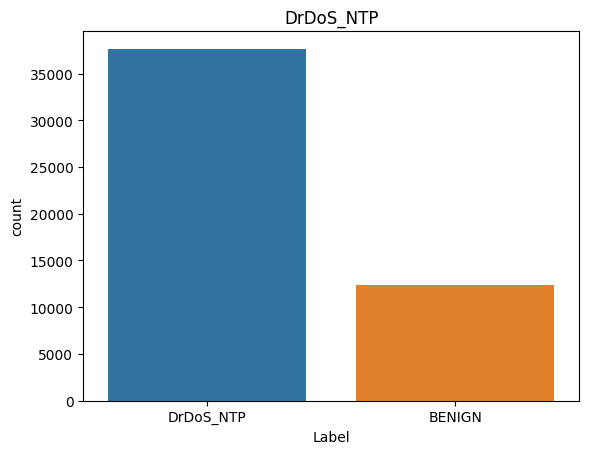

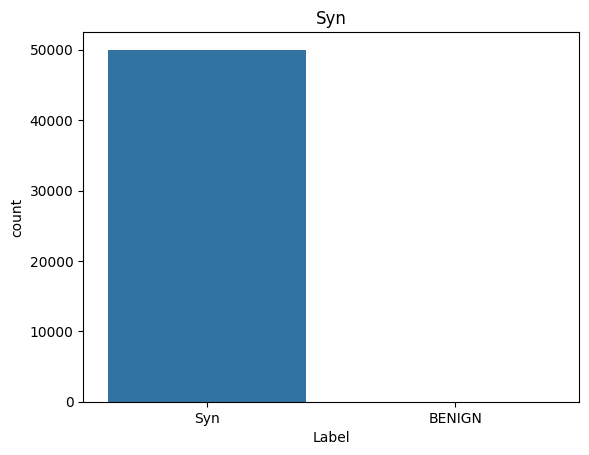

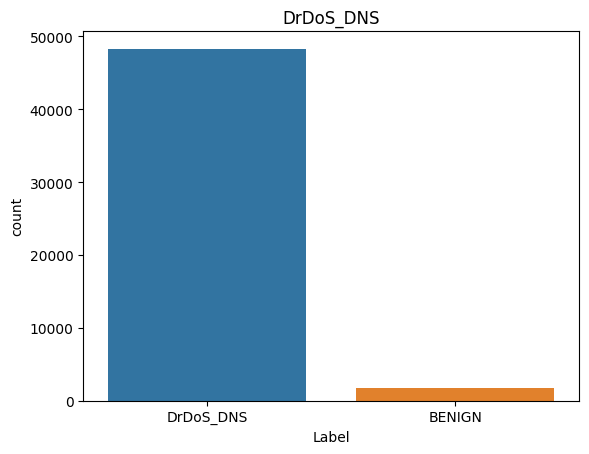

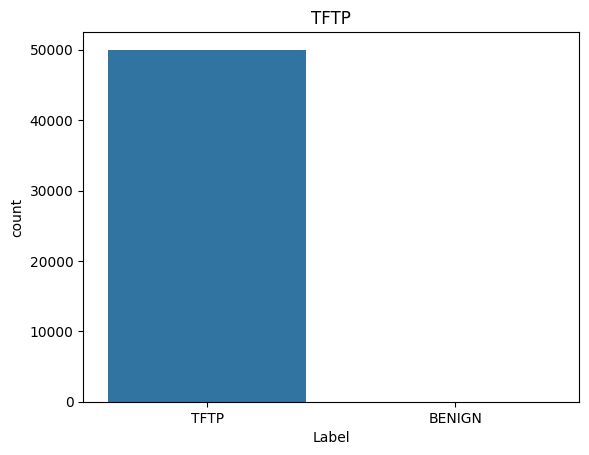

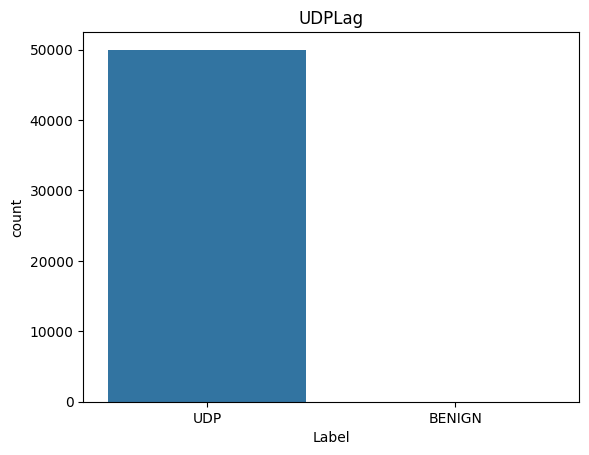

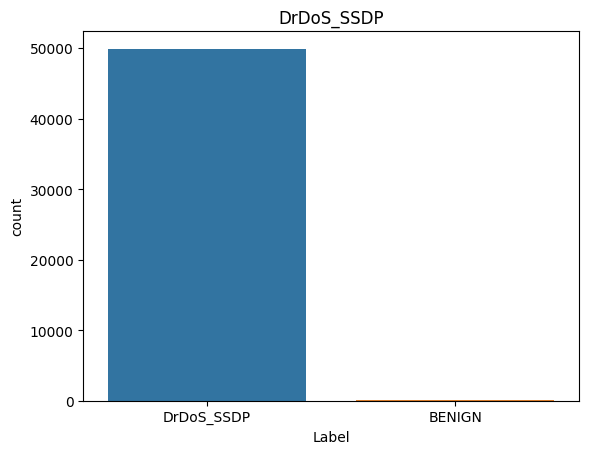

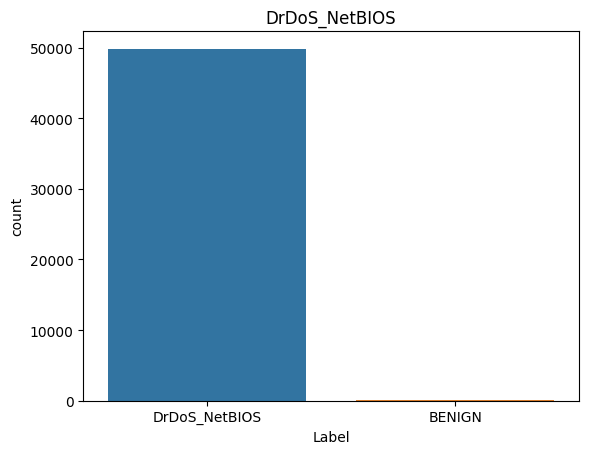

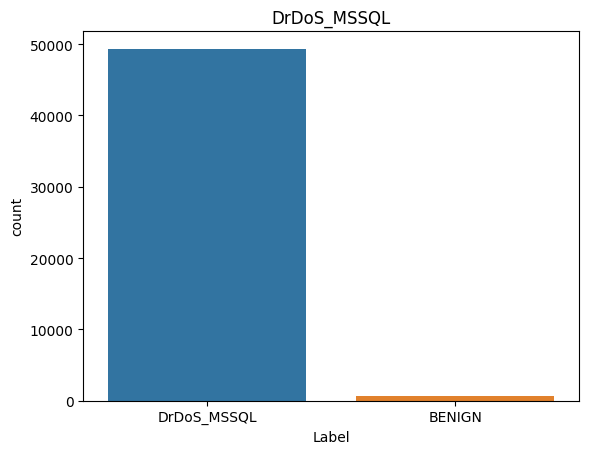

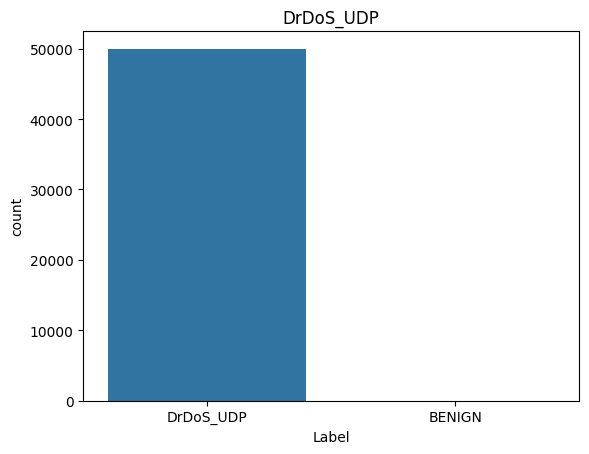

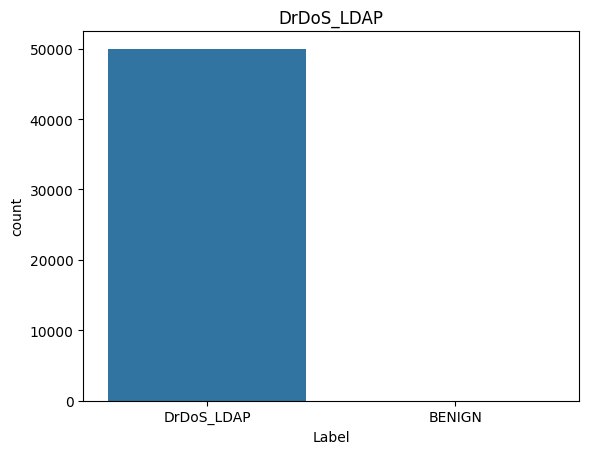

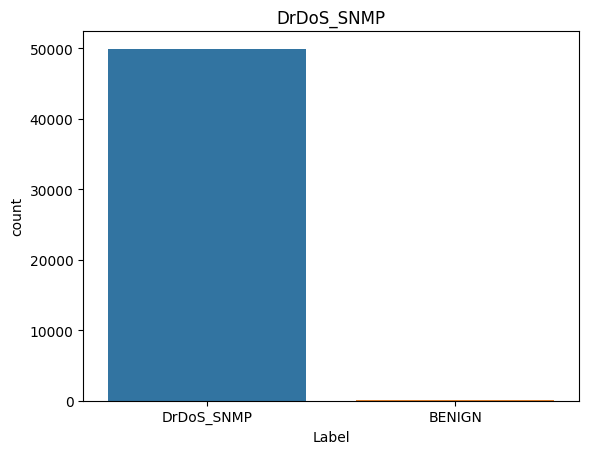

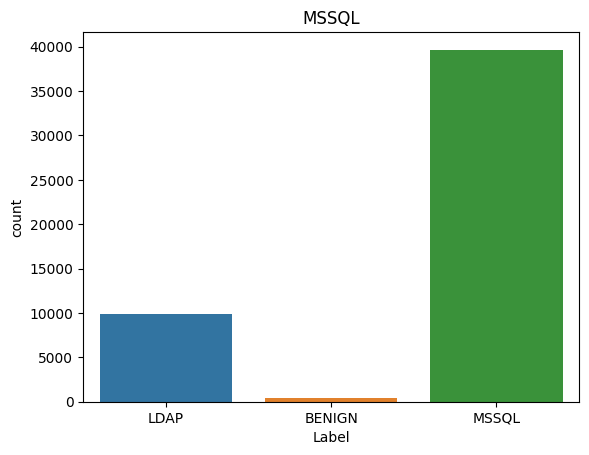

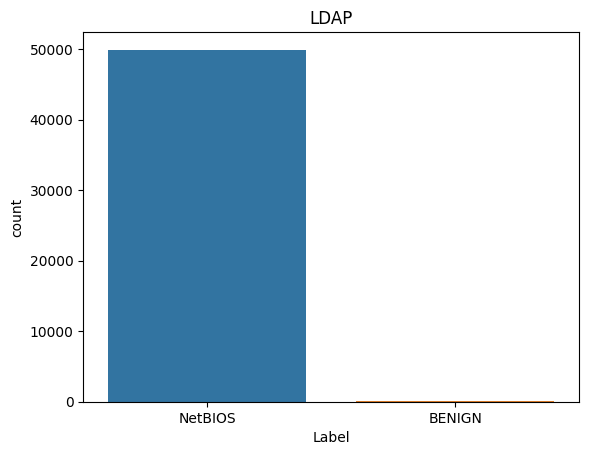

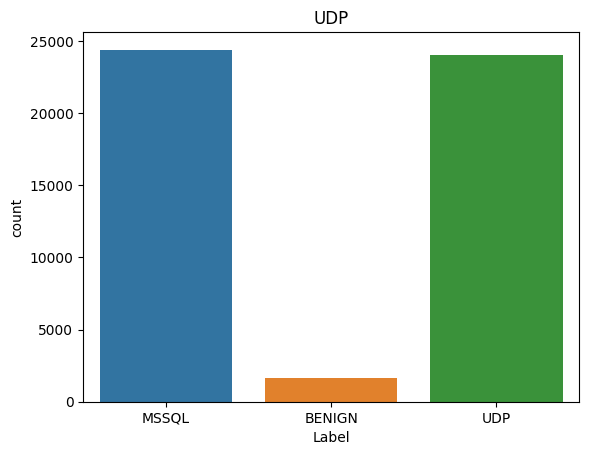

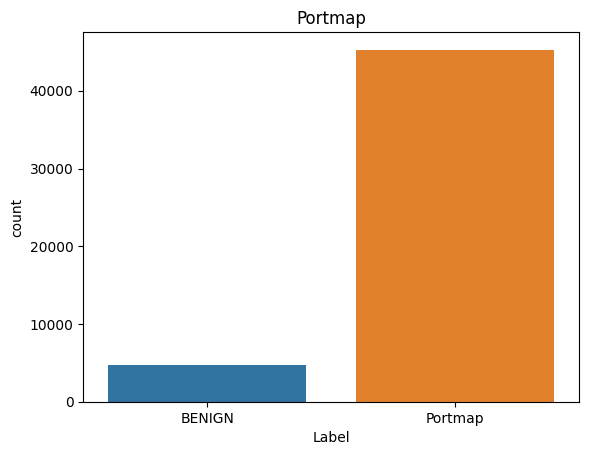

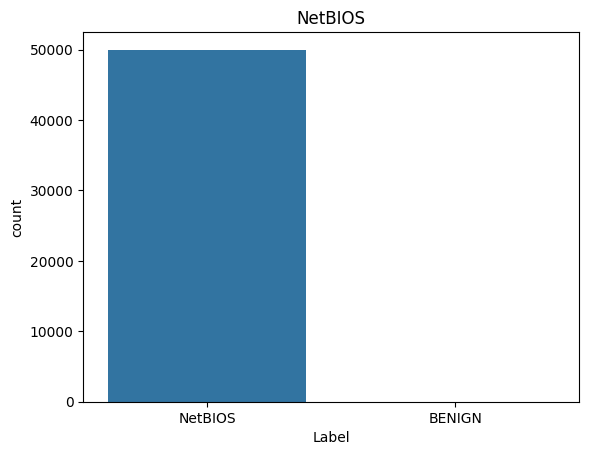

In [5]:
for key in loaded_dataset.keys():
    sns.countplot(data = loaded_dataset[key], x = 'Label', hue = 'Label')
    plt.title(key)
    plt.show()

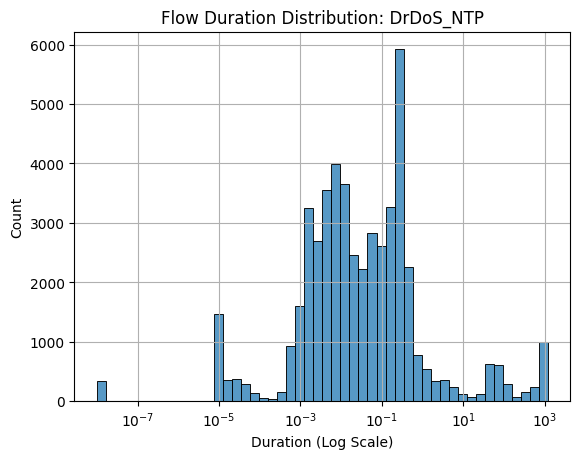

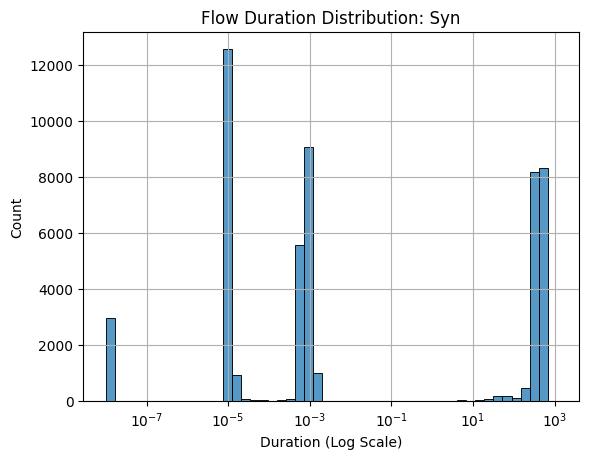

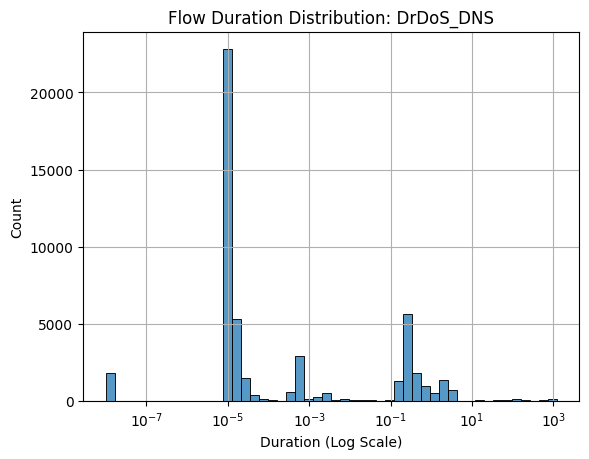

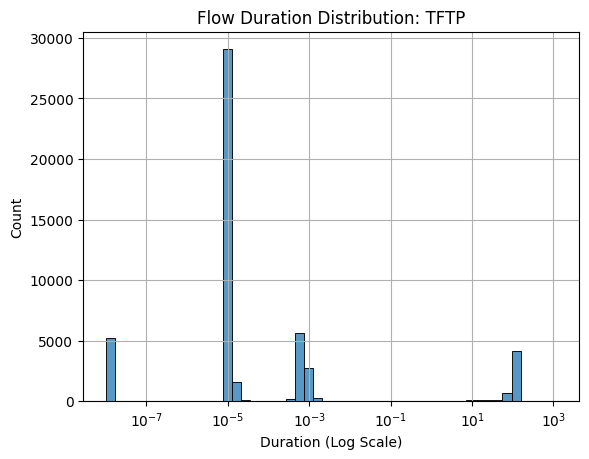

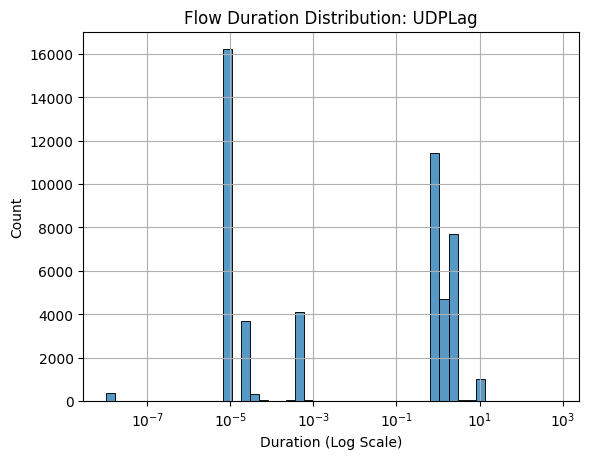

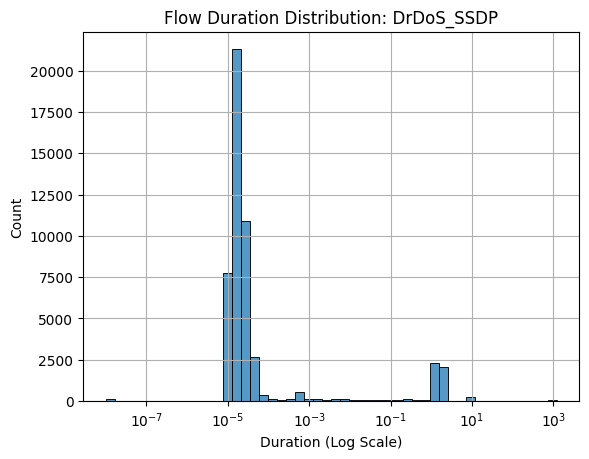

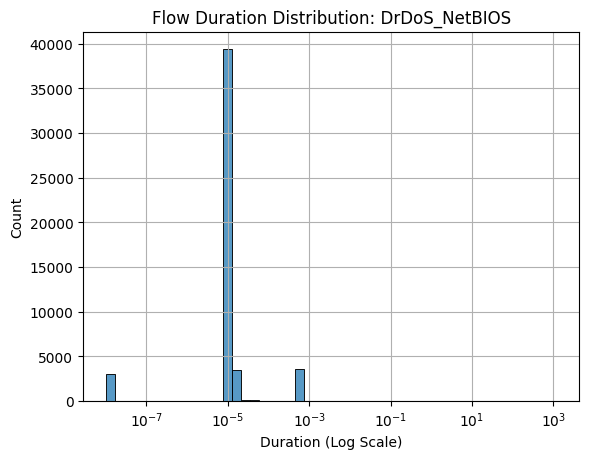

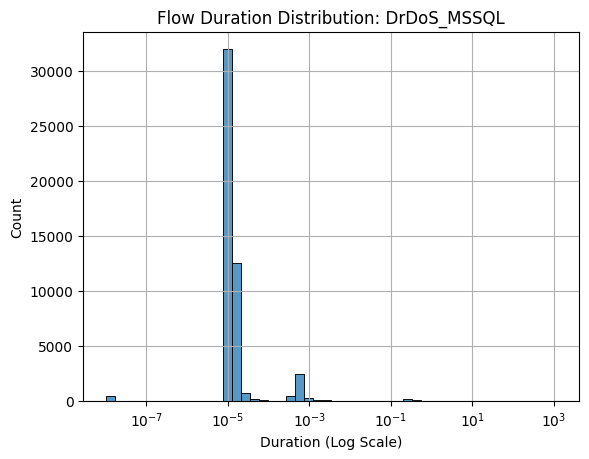

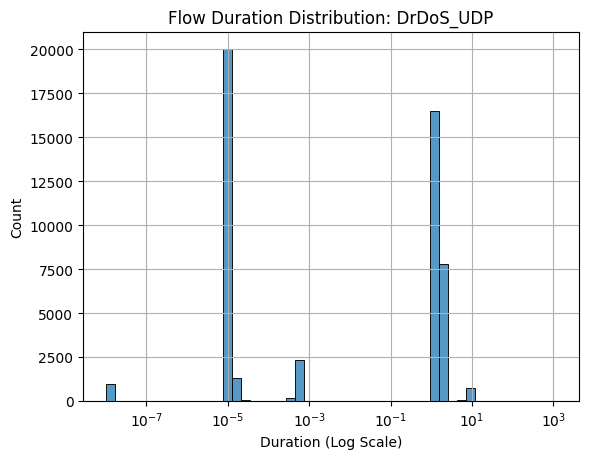

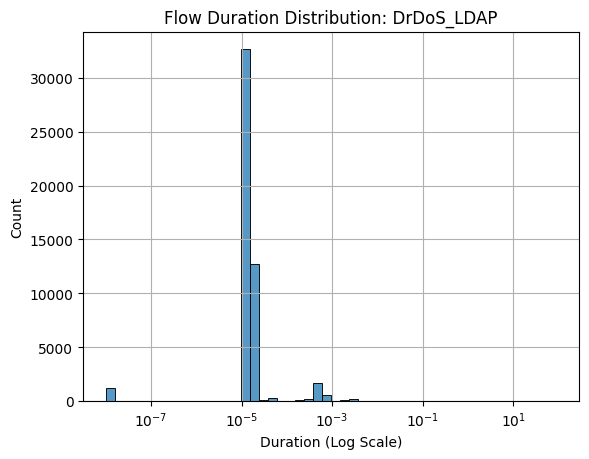

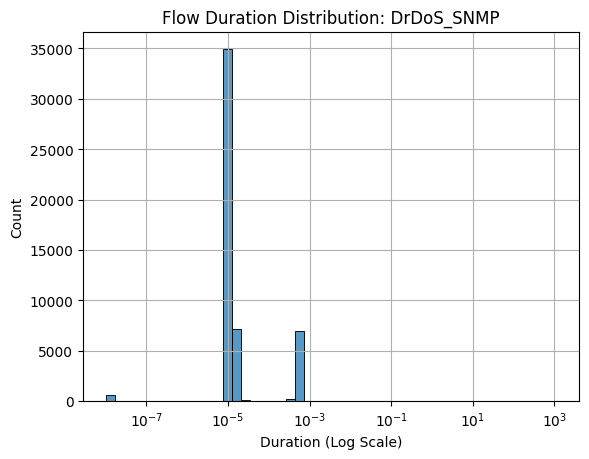

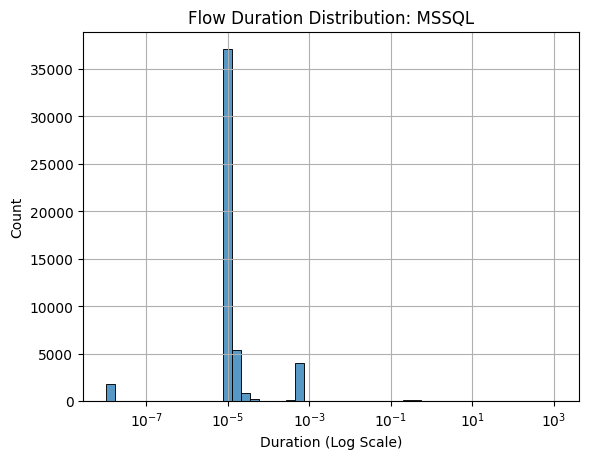

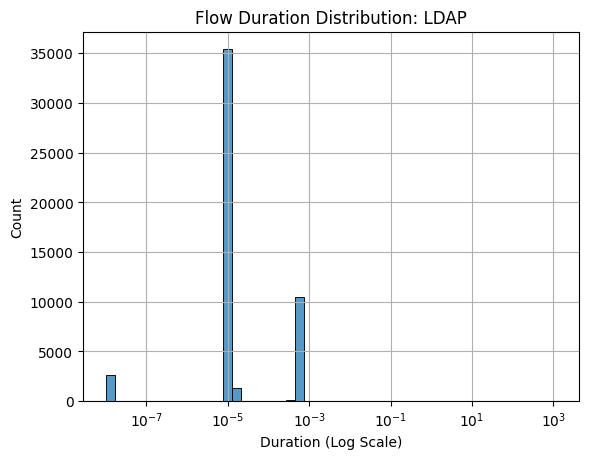

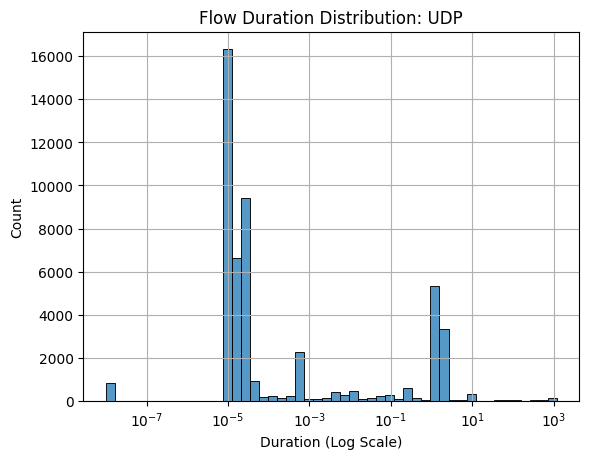

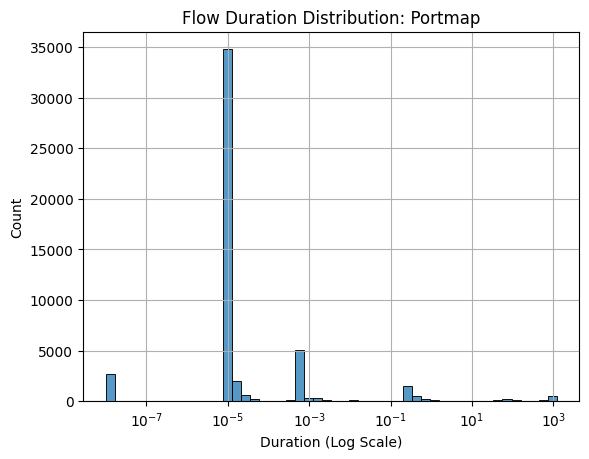

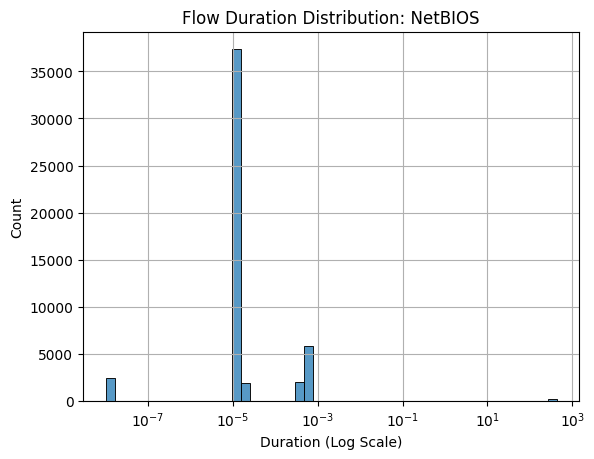

In [11]:
for i in loaded_dataset.keys():
    df = loaded_dataset[i].with_columns(
        pl.col('Flow Duration').cast(pl.Float64, strict=False))
    
    df = df.filter(
        pl.col('Flow Duration').is_not_null() & 
        pl.col('Flow Duration').is_finite())
    
    label = ((df['Flow Duration'] + 0.001) / 100000).to_numpy()
    
    sns.histplot(label, bins=50, log_scale=True)
    
    plt.title(f"Flow Duration Distribution: {i}")
    plt.xlabel("Duration (Log Scale)")
    plt.ylabel("Count")
    plt.grid()
    plt.show()

In [10]:
df = loaded_dataset['Syn'] 
df.columns

['Unnamed: 0',
 'Flow ID',
 'Source IP',
 'Source Port',
 'Destination IP',
 'Destination Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Varianc

/Users/kanishkbhagat/ML/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/kanishkbhagat/ML/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


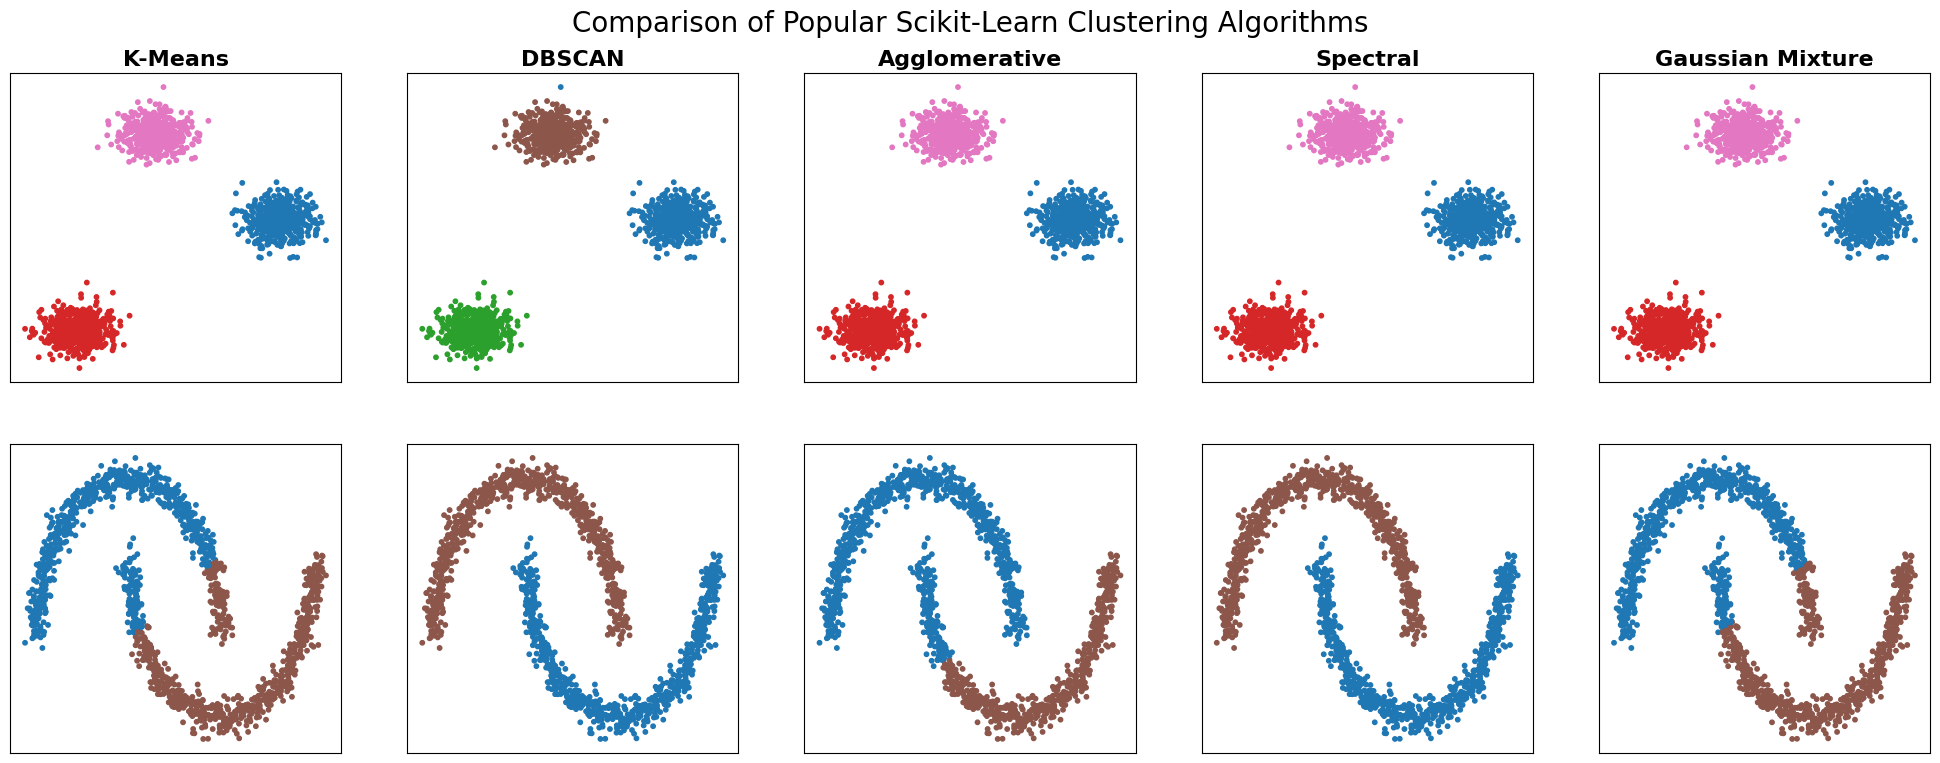

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture

# 1. Generate Synthetic Datasets
n_samples = 1500
random_state = 42

# Dataset A: Standard Blobs (Good for K-Means/GMM)
blobs_X, _ = datasets.make_blobs(n_samples=n_samples, random_state=random_state)

# Dataset B: Non-linear Moons (Good for DBSCAN/Spectral)
moons_X, _ = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=random_state)

# Normalize datasets for better performance across algorithms
datasets_to_test = [
    StandardScaler().fit_transform(blobs_X),
    StandardScaler().fit_transform(moons_X)
]

# 2. Define Clustering Algorithms
def get_clustering_algorithms():
    return [
        ("K-Means", KMeans(n_clusters=3, random_state=random_state, n_init=10)),
        ("DBSCAN", DBSCAN(eps=0.2, min_samples=5)),
        ("Agglomerative", AgglomerativeClustering(n_clusters=3, linkage='ward')),
        ("Spectral", SpectralClustering(n_clusters=3, eigen_solver='arpack', affinity="nearest_neighbors")),
        ("Gaussian Mixture", GaussianMixture(n_components=3, covariance_type='full', random_state=random_state))
    ]

# 3. Plotting Setup
fig, axes = plt.subplots(len(datasets_to_test), 5, figsize=(20, 8))
plt.subplots_adjust(left=.02, right=.98, bottom=.05, top=.9)

# 4. Execute and Plot
for dataset_idx, X in enumerate(datasets_to_test):
    algorithms = get_clustering_algorithms()
    
    # Adjust parameters specifically for the 'Moons' dataset (2 clusters instead of 3)
    if dataset_idx == 1: 
        algorithms[0][1].set_params(n_clusters=2) # K-Means
        algorithms[2][1].set_params(n_clusters=2) # Agglomerative
        algorithms[3][1].set_params(n_clusters=2) # Spectral
        algorithms[4][1].set_params(n_components=2) # GMM

    for algo_idx, (name, algorithm) in enumerate(algorithms):
        ax = axes[dataset_idx, algo_idx]
        
        # Fit and predict
        if name == "Gaussian Mixture":
            algorithm.fit(X)
            y_pred = algorithm.predict(X)
        else:
            y_pred = algorithm.fit_predict(X)
            
        # Scatter plot
        colors = plt.cm.tab10(y_pred.astype(float) / max(1, len(np.unique(y_pred))))
        ax.scatter(X[:, 0], X[:, 1], s=10, color=colors)
        
        # Formatting
        ax.set_xticks(())
        ax.set_yticks(())
        if dataset_idx == 0:
            ax.set_title(name, size=16, weight='bold')

plt.suptitle("Comparison of Popular Scikit-Learn Clustering Algorithms", size=20)
plt.show()